# TS1: Síntesis y operaciones de señales
## Alumno: Matías Carbajal
## Materia: Análisis y Procesamiento de Señales (APS)
## Carrera: Ingeniería Telecomunicaciones
## Fecha: 2 de septiembre de 2026

# 1. Introducción teórica

## 1.1. Señales

### 1.1.1 Señal senoidal

Una señal senoidal puede expresarse como:

$$x(t)=A\cos(2\pi f_0t+\phi)$$

Para una señal senoidal de valor medio nulo, su potencia media está relacionada con su amplitud mediante

$$P=\frac{A^2}{2}$$

Por lo tanto, para una señal senoidal con una potencia media determinada, su amplitud puede obtenerse a partir de

$$A=\sqrt{2P}$$

En particular, para una potencia de $2\text{ W}$, la amplitud correspondiente es

$$A=\sqrt{2(2)}=2\text{ V}$$

### 1.1.2 Ruido aleatorio y varianza


A diferencia de una señal determinística, una señal de ruido puede modelarse mediante variables aleatorias. Una característica importante de una señal aleatoria es su valor medio

$$\mu_X=E[X]$$

y su varianza

$$\sigma_X^2=E[(X-\mu_X)^2].$$

Para una señal cuyo valor medio es cero, la varianza queda directamente relacionada con su potencia media:

$$P=\sigma_X^2.$$

Para el ruido normalmente distribuido se utiliza una distribución gaussiana con

$$\mu=0, \qquad \sigma^2=0.1.$$


### 1.1.3 Pulso rectangular

El pulso rectangular es una señal que alterna entre dos niveles durante cada período. Una característica importante es su ciclo de actividad o *duty cycle*, definido como la fracción del período durante la cual la señal permanece en su nivel activo.

Para un ciclo de actividad del $50\%$, el pulso permanece en su estado activo durante la mitad de cada período y en el estado inactivo durante la otra mitad.

En esta práctica el pulso rectangular tiene la misma frecuencia fundamental que la señal sinusoidal, es decir,

$$f_0=2\text{ kHz}.$$

Además, se ajusta su amplitud para obtener una potencia media de $1\text{ W}$.

## 1.2. Transformada Discreta de Fourier

Para estudiar el contenido frecuencial de las señales generadas se utiliza la Transformada Discreta de Fourier. Para una secuencia de $N$ muestras $x[n]$, la DFT se define como

$$X[k]=\sum_{n=0}^{N-1}x[n]e^{-j2\pi kn/N}, \qquad k=0,\ldots,N-1.$$

Los coeficientes $X[k]$ son números complejos y contienen información tanto de amplitud como de fase. En esta práctica se representa principalmente el módulo de la transformada

$$|X[k]|.$$

De esta manera es posible observar cómo se distribuye la señal en frecuencia. Por ejemplo, una señal sinusoidal ideal presenta componentes espectrales concentradas alrededor de su frecuencia fundamental, mientras que una señal de ruido presenta un contenido espectral distribuido en un rango mucho más amplio.

Para una señal de $N$ muestras obtenidas a una frecuencia de muestreo $f_s$, la separación entre dos puntos consecutivos del espectro es

$$\Delta f=\frac{f_s}{N}.$$

Por lo tanto, tanto la frecuencia de muestreo como la cantidad de muestras determinan la resolución frecuencial del análisis.

## 1.3. Teorema de Parseval

El Teorema de Parseval permite relacionar la energía de una señal en el dominio temporal con la energía de sus coeficientes en el dominio frecuencial.
$$\sum_{n=0}^{N-1}|x[n]|^2 = \frac{1}{N}\sum_{k=0}^{N-1}|X[k]|^2.$$

Esto significa que la energía calculada a partir de las muestras de la señal es igual a la energía obtenida a partir de sus coeficientes de Fourier, teniendo en cuenta el factor de normalización correspondiente.


## 2. Desarrollo de consignas 

### 2.1 Parámetros y funciones

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import signal

# Parámetros del sistema
N = 1000
fs = 20000
ff = 2000 
SNRdb = 40
vmax = 2   
dc = 0
ph = np.pi/2
delta_f = fs/N

def mi_funcion_sen(vmax=1, dc=0, ff=1, ph=0, nn=1000, fs=1000):
    tt = np.arange(0, nn / fs, 1 / fs)
    xx = dc + vmax * np.sin(2 * np.pi * tt * ff + ph)
    return (tt, xx)

### 2.2 Señal sinusoidal de 2 kHz.

In [6]:
# 1. Señal Senoidal
tt, xx_sen = mi_funcion_sen(vmax=vmax, dc=dc, ff=ff, ph=ph, nn=N, fs=fs)
XX_sen = np.fft.fft(xx_sen)

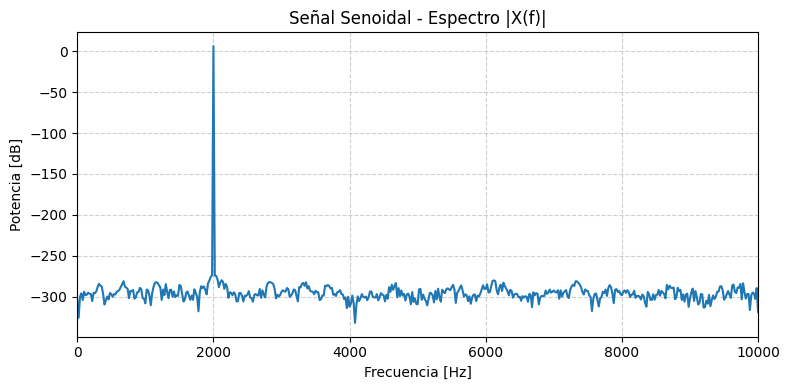

In [7]:
# Vector de frecuencias (0 a fs/2)
frecs = np.arange(0, N) * fs / N
plt.figure(figsize=(8, 4))
plt.xlim(0, fs/2)
plt.plot(frecs, 10*np.log10((2*np.abs(XX_sen)/N)**2), color='tab:blue')
plt.title('Señal Senoidal - Espectro |X(f)|')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Potencia [dB]')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

### 2.3 Ruido Gaussiano

In [8]:
ruido = np.random.normal(loc=0, scale=np.sqrt(0.1), size=N)
XX_ruido = np.fft.fft(ruido)

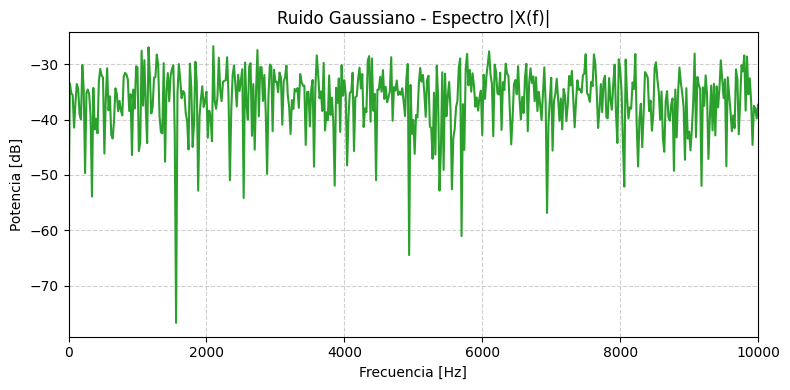

In [9]:
plt.figure(figsize=(8, 4))
plt.xlim(0, fs/2)
plt.plot(frecs, 10*np.log10((2*np.abs(XX_ruido)/N)**2), color='tab:green')
plt.title('Ruido Gaussiano - Espectro |X(f)|')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Potencia [dB]')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

### 2.4 Ruido uniforme

In [10]:
a = np.sqrt(0.3)
xx_unif = np.random.uniform(low=-a, high=a, size=N)
XX_unif = np.fft.fft(xx_unif)

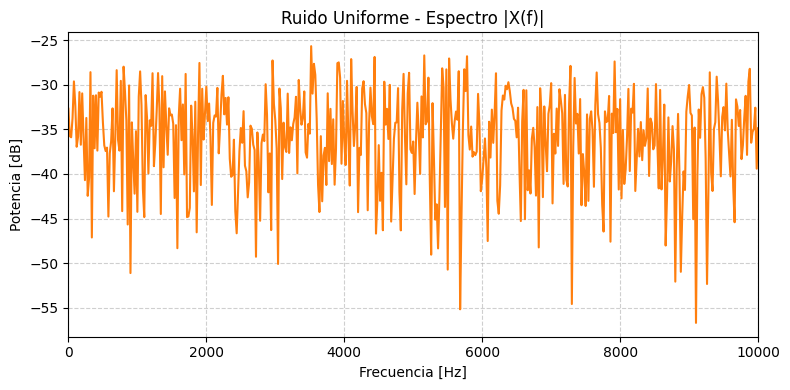

In [11]:
plt.figure(figsize=(8, 4))
plt.xlim(0, fs/2)
plt.plot(frecs, 10*np.log10((2*np.abs(XX_unif)/N)**2), color='tab:orange')
plt.title('Ruido Uniforme - Espectro |X(f)|')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Potencia [dB]')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()


### 2.5 Señal Cuadrada

In [12]:
sq_tt = np.arange(0, N/fs, 1/fs)
xx_sq = signal.square(2*np.pi*ff*sq_tt, duty=0.5)
XX_sq = np.fft.fft(xx_sq)

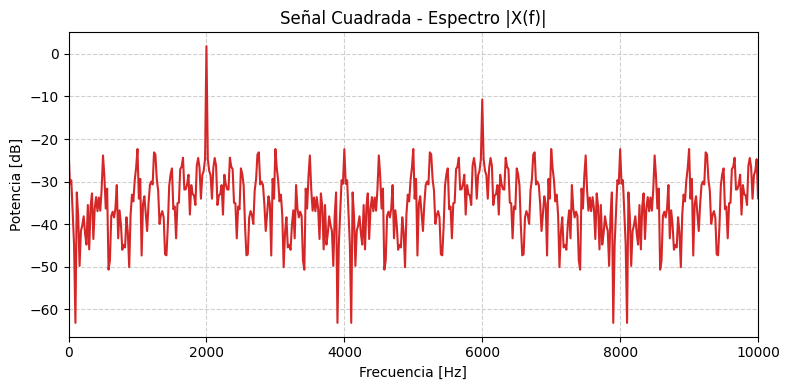

In [13]:
plt.figure(figsize=(8, 4))
plt.xlim(0, fs/2)
plt.plot(frecs, 10*np.log10((2*np.abs(XX_sq)/N)**2), color='tab:red')
plt.title('Señal Cuadrada - Espectro |X(f)|')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Potencia [dB]')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()


# 3. Análisis de los espectros obtenidos

Para todas las señales se utilizó una frecuencia de muestreo $f_s = 20\text{ kHz}$ y $N = 1000$ muestras. Por lo tanto, la resolución en frecuencia de la DFT es:

$$\Delta f = \frac{f_s}{N} = 20\text{ Hz}$$

Además, para la señal de $2\text{ kHz}$ se obtienen:

$$\frac{f_s}{f_0} = \frac{20000}{2000} = 10\text{ muestras por período}$$

cumpliendo con la condición mínima solicitada.



## 3.1. Señal senoidal

El espectro de la señal senoidal presenta un pico claramente definido en $2\text{ kHz}$, correspondiente a la frecuencia de la señal. Al tratarse de una señal sinusoidal ideal, prácticamente toda su energía se concentra en dicha frecuencia (y en su componente simétrica correspondiente en el espectro completo de la DFT).

La señal posee una amplitud pico $A = 2\text{ V}$, por lo que su potencia media es:

$$P = \frac{A^2}{2} = \frac{2^2}{2} = 2\text{ W}$$

Al normalizar el espectro arroja el valor exacto de la amplitud pico $A = 2\text{ V}$. Al llevarlo a escala en dB mediante  esto nos da un valor de:

$$\text{Pico espectral [dB]} = 10 \log_{10}(2^2) = 10 \log_{10}(4) \approx 6.02\text{ dB}$$



## 3.2. Ruido gaussiano

El espectro del ruido gaussiano presenta componentes distribuidas de manera continua a lo largo de todo el rango de frecuencias (de $0$ a $f_s/2$), sin un pico dominante. Esto se debe a que el ruido aleatorio es una señal no periódica que reparte su energía en todo el ancho de banda disponible.

Como el ruido fue generado con media nula y varianza teórica $\sigma^2 = 0.1\text{ W}$, su potencia media esperada es aproximadamente $0.1\text{ W}$. Las pequeñas fluctuaciones respecto de este valor teórico se deben al carácter estocástico de la señal y al número finito de muestras ($N=1000$).



## 3.3. Ruido uniforme

El ruido uniforme también presenta un espectro plano y distribuido en un amplio rango de frecuencias, sin una componente espectral dominante. Su comportamiento espectral general es similar al del ruido gaussiano, aunque proviene de una distribución de probabilidad distinta.

Para obtener una varianza teórica de $0.1\text{ W}$, se utilizó una distribución uniforme continua en el intervalo $[-a, +a]$. Como para una distribución $U(-a, a)$ la varianza es:

$$\sigma^2 = \frac{(2a)^2}{12} = \frac{a^2}{3} = 0.1\text{ W}$$

Se obtiene la amplitud límite:

$$a = \sqrt{0.3} \approx 0.5477\text{ V}$$



## 3.4. Señal rectangular 

El espectro de la señal rectangular presenta un conjunto discreto de componentes espectrales compuestas por la frecuencia fundamental y sus **armónicos impares**. Esto es característico de una onda cuadrada simétrica con ciclo de actividad del 50%.

* La componente fundamental se encuentra en $2\text{ kHz}$.
* Los armónicos impares aparecen en $6\text{ kHz}$, $10\text{ kHz}$, $14\text{ kHz}$, etc.
* La envolvente de las amplitudes decrece a razón de $1/k$ (o $-20\text{ dB/década}$) a medida que aumenta la frecuencia, siguiendo la forma de una función $\text{sinc}(f)$.

Debido a que la señal conmuta entre $+1\text{ V}$ y $-1\text{ V}$, su potencia media es:

$$P = \frac{1}{N} \sum |x[n]|^2 = 1^2 = 1\text{ W}$$



# 4. Conclusiónes

A partir de las señales generadas se pudo analizar su comportamiento tanto en el dominio temporal como en el dominio frecuencial. Se verificó que la señal senoidal concentra su energía en su frecuencia fundamental, mientras que los ruidos presentan componentes distribuidas en un amplio rango de frecuencias y la señal rectangular presenta su frecuencia fundamental y sus armónicos.

# Bonus:

In [19]:
# Potencia en el dominio temporal
P_t = np.mean(np.abs(xx_sen)**2)

# Transformada de Fourier
XX = np.fft.fft(xx_sen)

# Potencia mediante Parseval
P_f = np.sum(np.abs(XX)**2) / N**2

print("Potencia temporal:", P_t, "W")
print("Potencia mediante Fourier:", P_f, "W")

Potencia temporal: 1.9999999999999947 W
Potencia mediante Fourier: 1.9999999999999953 W
